# PostHog contributor impact — exploratory data analysis

This notebook looks at the **shape** of a 90-day extract from `posthog/posthog` before any impact ranking.
Each row is one commit. PR, issue, and comment fields are lists because a commit can sit on more than one PR and a PR can close more than one issue.

**How to run** (from `notebooks/`):

```bash
uv sync
uv run jupyter lab eda.ipynb
```

Pick the kernel from `notebooks/.venv`. Section 0 loads `github_etl/data/contributor_commits.parquet` and validates it with `github_etl.schemas.FinalCommitSchema`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from github_etl.schemas import FinalCommitSchema

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)

## 0. Load data

Rows come from the ETL's `contributor_commits.parquet`. Validation uses `FinalCommitSchema` imported from `github_etl` (same module the pipeline writes against), not a local copy.
Parquet round-trips list columns as NumPy arrays, so we coerce them back to Python `list` before the schema's list checks.

In [2]:
LIST_COLS = [
    "branch",
    "pr",
    "pr_state",
    "number_of_comments_on_pr",
    "connected_issue",
    "number_of_comments_on_connected_issue",
]


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    marker = Path("github_etl") / "src" / "github_etl" / "schemas.py"
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find github_etl/src/github_etl/schemas.py. "
        "Run Jupyter from the repo root or notebooks/."
    )


def to_python_list(value: object) -> list:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, list):
        return value
    return list(value)


def quantile_summary(series: pd.Series, label: str) -> pd.Series:
    return pd.Series(
        {
            "count": int(series.count()),
            "min": series.min(),
            "q25": series.quantile(0.25),
            "median": series.median(),
            "q75": series.quantile(0.75),
            "max": series.max(),
            "mean": series.mean(),
        },
        name=label,
    )


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "github_etl" / "data" / "contributor_commits.parquet"
df = pd.read_parquet(DATA_PATH)
for col in LIST_COLS:
    df[col] = df[col].map(to_python_list)
df["committed_at"] = pd.to_datetime(df["committed_at"], utc=True)
df = FinalCommitSchema.validate(df)

print(f"loaded {DATA_PATH}")
print("schema: github_etl.schemas.FinalCommitSchema")
print(f"rows={len(df):,}  columns={list(df.columns)}")
print(
    "window: "
    f"{df['committed_at'].min().date()} → {df['committed_at'].max().date()} "
    f"({df['committed_at'].dt.normalize().nunique()} distinct days)"
)
df.head()


loaded /Users/steffen/Documents/posthog_contributor_impact/github_etl/data/contributor_commits.parquet
schema: github_etl.schemas.FinalCommitSchema
rows=13,202  columns=['commit_id', 'committed_at', 'contributor', 'branch', 'pr', 'pr_state', 'number_of_comments_on_pr', 'has_pr_been_merged_into_main', 'connected_issue', 'number_of_comments_on_connected_issue']
window: 2026-05-20 → 2026-08-18 (91 distinct days)


,commit_id,committed_at,contributor,branch,pr,pr_state,number_of_comments_on_pr,has_pr_been_merged_into_main,connected_issue,number_of_comments_on_connected_issue
0,00036d38ae536175d63455c0d0055affe43250cc,2026-07-27 11:48:12+00:00,Gilbert09,[posthog-code/fix-shopify-401-non-retryable],[73802],[MERGED],[2],True,[],[]
1,00069ca66a70af631a6008c3eb7fa4eae1d5c87f,2026-06-04 14:58:32+00:00,MattPua,[06-03-feat_dashboards_show_widget_placeholders_on_shared_dashboards],[61416],[MERGED],[19],True,[],[]
2,000d0abdab8c45eb5456741c68a361562a5b8fc8,2026-06-17 19:55:16+00:00,TueHaulund,[tue/replay-vision-signals],[63224],[MERGED],[22],True,[],[]
3,0011a28f7a484a830ed03981c81a29830eeb7e51,2026-07-17 07:15:19+00:00,ablaszkiewicz,[posthog-code/error-tracking-widget-decouple-autocapture],[71608],[MERGED],[8],True,[],[]
4,00190e9730a80a958eb052c5803c42e0be1e3524,2026-08-13 15:46:22+00:00,nickbest-ph,[nick/personhog-merge-small-fixes],[82270],[MERGED],[7],True,[],[]


## 1. Commits

Three views of the same grain (the commit):

1. **How many commits** landed in the window, and how that volume is spread **across days** (min / quartiles / max of the daily totals, then a bar chart).
2. How that volume is spread **across contributors** (min / quartiles / max of each person's total).
3. Each contributor's **daily** commit series as a box plot, ordered by mean daily commits. Zero-commit days are included so the mean is an activity rate over the full window, not just days they happened to push.

In [3]:
n_commits = len(df)
n_unattributed = int(df["contributor"].isna().sum())
n_contributors = int(df["contributor"].nunique(dropna=True))
print(f"total commits: {n_commits:,}")
print(f"contributors with a login: {n_contributors}")
print(f"commits with no contributor: {n_unattributed:,}")

total commits: 13,202
contributors with a login: 210
commits with no contributor: 0


,commits_per_day
count,91.000000
min,4.000000
q25,29.000000
median,170.000000
q75,216.500000
max,324.000000
mean,145.076923


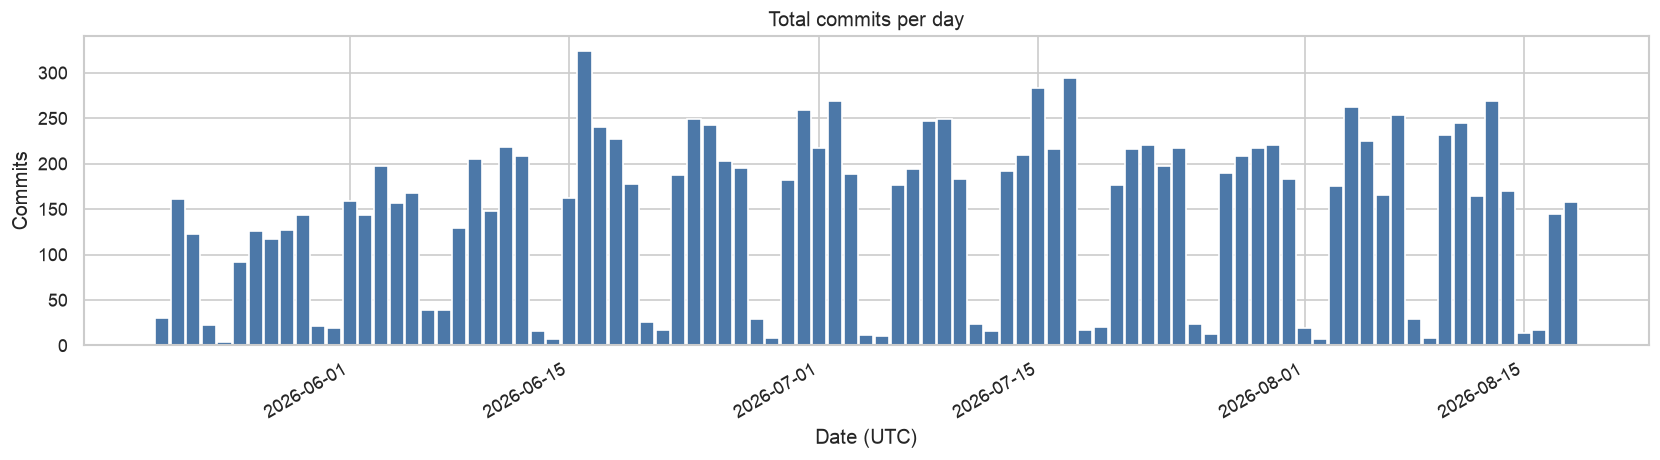

In [4]:
df = df.copy()
df["day"] = df["committed_at"].dt.tz_convert("UTC").dt.normalize()

day_index = pd.date_range(df["day"].min(), df["day"].max(), freq="D", tz="UTC")
commits_per_day = (
    df.groupby("day").size().rename("commits").reindex(day_index, fill_value=0)
)
commits_per_day.index.name = "day"

display(quantile_summary(commits_per_day, "commits_per_day").to_frame())

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(commits_per_day.index, commits_per_day.values, width=0.9, color="#4c78a8")
ax.set_title("Total commits per day")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Commits")
fig.autofmt_xdate()
fig.tight_layout()

In [5]:
commits_per_contributor = (
    df.dropna(subset=["contributor"]).groupby("contributor").size().rename("commits")
)

display(quantile_summary(commits_per_contributor, "commits_per_contributor").to_frame())
display(
    commits_per_contributor.sort_values(ascending=False)
    .head(10)
    .to_frame()
    .rename_axis("contributor")
)

,commits_per_contributor
count,210.000000
min,1.000000
q25,2.000000
median,18.000000
q75,82.750000
max,2208.000000
mean,62.866667


,commits
contributor,
Gilbert09,2208
posthog[bot],535
pauldambra,500
andrewm4894,351
sampennington,341
rnegron,283
webjunkie,233
jonmcwest,205
tatoalo,203


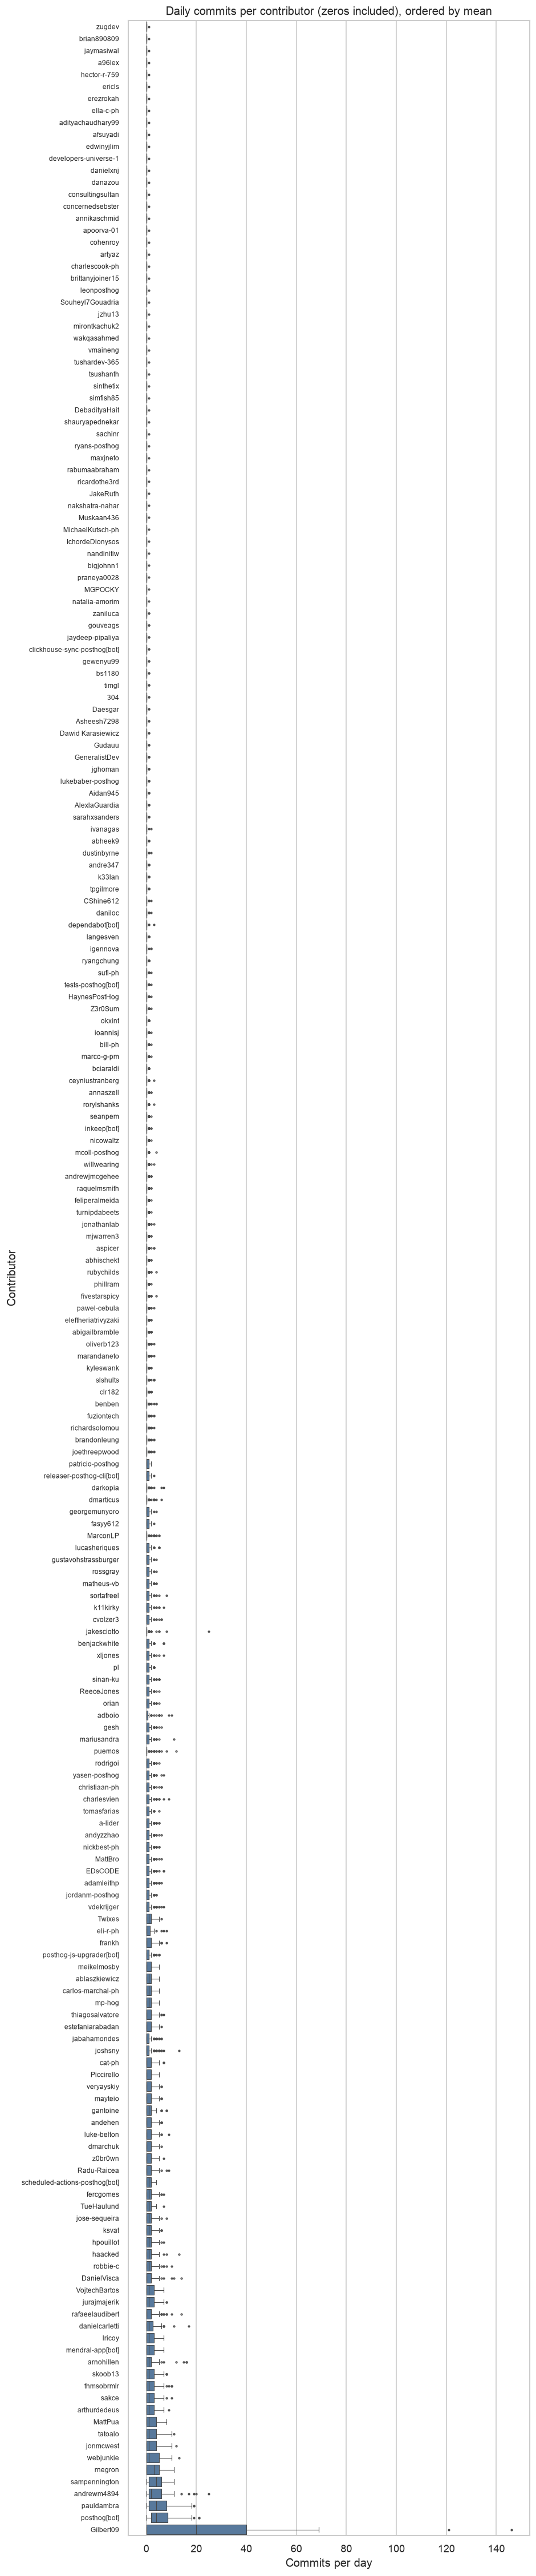

In [6]:
attributed = df.dropna(subset=["contributor"])
contributors = commits_per_contributor.index.tolist()
panel_index = pd.MultiIndex.from_product(
    [contributors, day_index], names=["contributor", "day"]
)
daily_by_contributor = (
    attributed.groupby(["contributor", "day"]).size().rename("commits")
    .reindex(panel_index, fill_value=0)
    .reset_index()
)

order = (
    daily_by_contributor.groupby("contributor")["commits"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(8, max(10, 0.18 * len(order))))
sns.boxplot(
    data=daily_by_contributor,
    x="commits",
    y="contributor",
    order=order,
    ax=ax,
    color="#4c78a8",
    fliersize=1.5,
    linewidth=0.7,
)
ax.set_title("Daily commits per contributor (zeros included), ordered by mean")
ax.set_xlabel("Commits per day")
ax.set_ylabel("Contributor")
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()

## 2. PRs and issues

The commit table stores PRs and issues as lists, so the unit here is the **unique PR** and **unique issue**, not the commit.

- **State mix:** share of distinct PRs that are `MERGED`, `OPEN`, or `CLOSED`. This extract is default-branch commits, so PRs attached to those commits are almost entirely `MERGED` — that is a selection effect of the ETL, not a claim about every PR in the repo.
- **Discussion volume:** comments per PR overlaid with comments per connected issue. Both are counts with a long right tail; overlaying them shows whether issues or PRs attract more discussion in this window.

unique PRs: 13,169


,count,proportion
Merged into master,"13,168",100.0%
Open,0,0.0%
Closed,0,0.0%


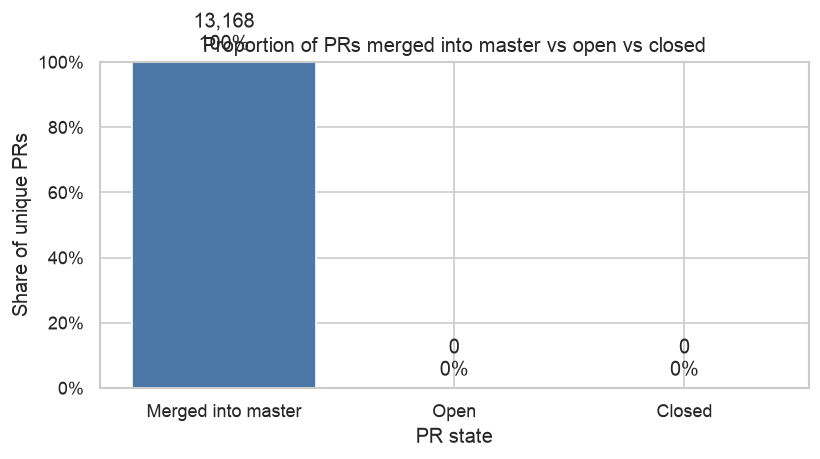

In [7]:
pr_table = (
    df[["pr", "pr_state", "number_of_comments_on_pr"]]
    .explode(["pr", "pr_state", "number_of_comments_on_pr"], ignore_index=True)
    .dropna(subset=["pr"])
    .drop_duplicates("pr")
    .copy()
)
pr_table["pr"] = pr_table["pr"].astype(int)
pr_table["number_of_comments_on_pr"] = pr_table["number_of_comments_on_pr"].astype(int)

state_order = ["MERGED", "OPEN", "CLOSED"]
state_labels = {
    "MERGED": "Merged into master",
    "OPEN": "Open",
    "CLOSED": "Closed",
}
state_counts = (
    pr_table["pr_state"].value_counts().reindex(state_order, fill_value=0).rename("count")
)
state_share = (state_counts / state_counts.sum()).rename("proportion")
state_summary = pd.concat([state_counts, state_share], axis=1)
state_summary.index = [state_labels[state] for state in state_summary.index]

print(f"unique PRs: {len(pr_table):,}")
display(state_summary.style.format({"count": "{:,.0f}", "proportion": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4c78a8", "#f58518", "#e45756"]
ax.bar(state_summary.index, state_summary["proportion"], color=colors)
ax.set_title("Proportion of PRs merged into master vs open vs closed")
ax.set_xlabel("PR state")
ax.set_ylabel("Share of unique PRs")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda x, _pos: f"{x:.0%}")
for i, (count, share) in enumerate(zip(state_summary["count"], state_summary["proportion"])):
    ax.text(i, share + 0.02, f"{int(count):,}\n{share:.0%}", ha="center", va="bottom")
fig.tight_layout()

unique connected issues: 241


,comments_per_pr,comments_per_issue
count,13169.000000,241.000000
min,0.000000,0.000000
q25,5.000000,0.000000
median,7.000000,0.000000
q75,11.000000,1.000000
max,836.000000,16.000000
mean,9.923001,1.041494


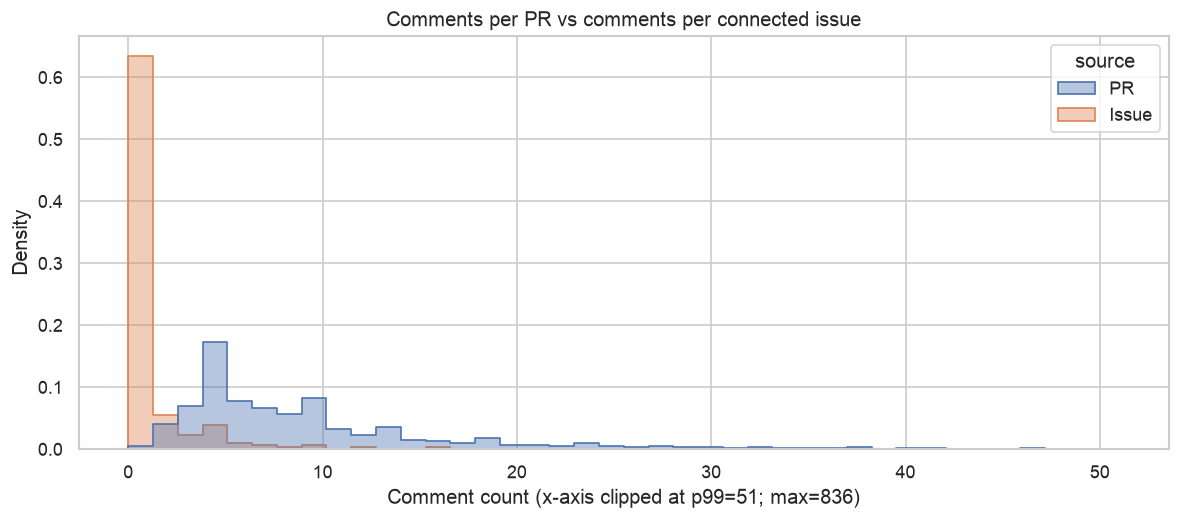

In [8]:
issue_table = (
    df[["connected_issue", "number_of_comments_on_connected_issue"]]
    .explode(
        ["connected_issue", "number_of_comments_on_connected_issue"],
        ignore_index=True,
    )
    .dropna(subset=["connected_issue"])
    .drop_duplicates("connected_issue")
    .copy()
)
issue_table["connected_issue"] = issue_table["connected_issue"].astype(int)
issue_table["number_of_comments_on_connected_issue"] = issue_table[
    "number_of_comments_on_connected_issue"
].astype(int)

comments = pd.concat(
    [
        pr_table["number_of_comments_on_pr"]
        .rename("comments")
        .to_frame()
        .assign(source="PR"),
        issue_table["number_of_comments_on_connected_issue"]
        .rename("comments")
        .to_frame()
        .assign(source="Issue"),
    ],
    ignore_index=True,
)

print(f"unique connected issues: {len(issue_table):,}")
display(
    pd.concat(
        [
            quantile_summary(pr_table["number_of_comments_on_pr"], "comments_per_pr"),
            quantile_summary(
                issue_table["number_of_comments_on_connected_issue"],
                "comments_per_issue",
            ),
        ],
        axis=1,
    )
)

max_comments = int(comments["comments"].max())
x_max = max(int(comments["comments"].quantile(0.99)), 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(
    data=comments,
    x="comments",
    hue="source",
    bins=40,
    binrange=(0, x_max),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.4,
    ax=ax,
)
ax.set_title("Comments per PR vs comments per connected issue")
ax.set_xlabel(f"Comment count (x-axis clipped at p99={x_max}; max={max_comments})")
ax.set_ylabel("Density")
fig.tight_layout()